In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

In [4]:
print("First 5 rows:\n", df.head())
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
print(df.info())
print("\nSummary:\n", df.describe())

First 5 rows:
    Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               764

In [5]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64



Year-wise Deliveries:
 Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64


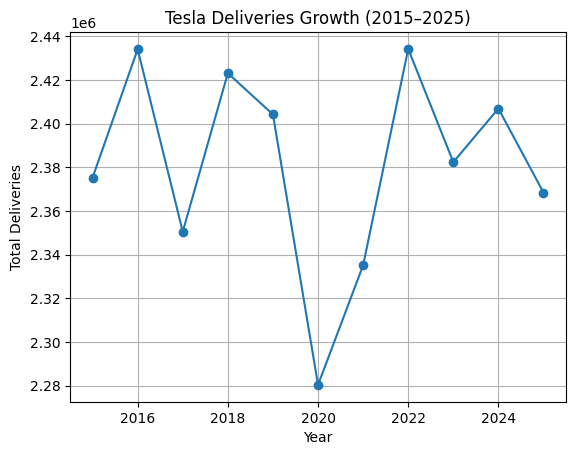

In [6]:
yearly = df.groupby("Year")["Estimated_Deliveries"].sum()

print("\nYear-wise Deliveries:\n", yearly)

plt.figure()
plt.plot(yearly.index, yearly.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Total Deliveries")
plt.title("Tesla Deliveries Growth (2015–2025)")
plt.grid()
plt.show()

In [7]:
model_data = df.groupby("Model")["Estimated_Deliveries"].sum()
print("\nModel-wise Deliveries:\n", model_data)


Model-wise Deliveries:
 Model
Cybertruck    5109779
Model 3       5321919
Model S       5380385
Model X       5157240
Model Y       5225284
Name: Estimated_Deliveries, dtype: int64


In [8]:
region_data = df.groupby("Region")["Estimated_Deliveries"].sum()
print("\nRegion-wise Deliveries:\n", region_data)


Region-wise Deliveries:
 Region
Asia             6539935
Europe           6494035
Middle East      6698045
North America    6462592
Name: Estimated_Deliveries, dtype: int64



CO2 Saved:
 Year
2015    182466.15
2016    185529.89
2017    172837.26
2018    183804.41
2019    180034.13
2020    171564.47
2021    179127.01
2022    178624.13
2023    173875.07
2024    176635.80
2025    179864.93
Name: CO2_Saved_tons, dtype: float64


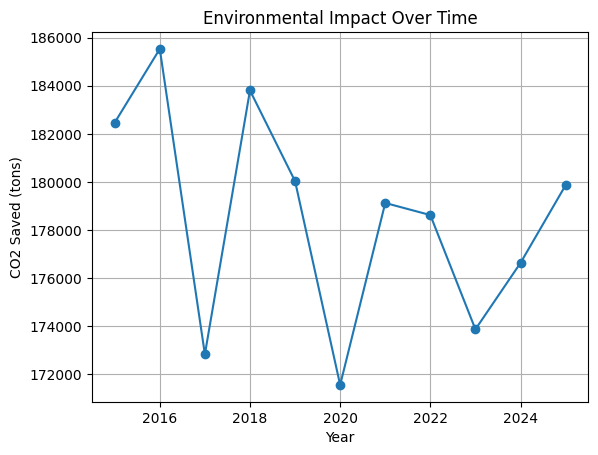

In [9]:
co2 = df.groupby("Year")["CO2_Saved_tons"].sum()

print("\nCO2 Saved:\n", co2)

plt.figure()
plt.plot(co2.index, co2.values, marker='o')
plt.xlabel("Year")
plt.ylabel("CO2 Saved (tons)")
plt.title("Environmental Impact Over Time")
plt.grid()
plt.show()


Charging Stations Growth:
 Year
2015    9269.012500
2016    8919.420833
2017    8653.562500
2018    8750.075000
2019    9017.975000
2020    8863.420833
2021    8909.716667
2022    8972.075000
2023    9100.670833
2024    9060.212500
2025    8737.329167
Name: Charging_Stations, dtype: float64


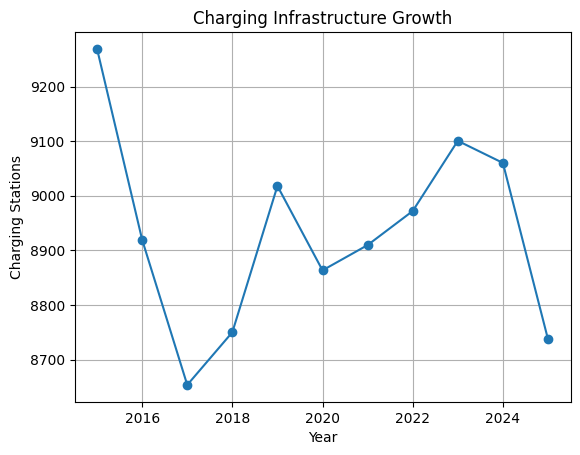

In [10]:
charging = df.groupby("Year")["Charging_Stations"].mean()

print("\nCharging Stations Growth:\n", charging)

plt.figure()
plt.plot(charging.index, charging.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Charging Stations")
plt.title("Charging Infrastructure Growth")
plt.grid()
plt.show()

In [11]:
corr = df.corr(numeric_only=True)
print("\nCorrelation Matrix:\n", corr)


Correlation Matrix:
                               Year         Month  Estimated_Deliveries  \
Year                  1.000000e+00  2.216119e-15             -0.002863   
Month                 2.216119e-15  1.000000e+00              0.030877   
Estimated_Deliveries -2.863112e-03  3.087690e-02              1.000000   
Production_Units     -2.760884e-03  2.897149e-02              0.994234   
Avg_Price_USD        -4.990980e-03  2.485676e-02             -0.027546   
Battery_Capacity_kWh -3.048584e-02  1.714479e-03             -0.007765   
Range_km             -2.912765e-02  2.142889e-03             -0.006606   
CO2_Saved_tons       -1.924402e-02  3.291988e-02              0.836814   
Charging_Stations    -3.465622e-03 -1.132526e-02              0.000753   

                      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  \
Year                         -0.002761      -0.004991             -0.030486   
Month                         0.028971       0.024857              0.001714   


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X = df[["Production_Units", "Avg_Price_USD", "Battery_Capacity_kWh"]]
y = df["Estimated_Deliveries"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, pred))

Mean Absolute Error: 321.1300945080094
